# Kiểm Thử Mô Hình - Pima Indians Diabetes

**Bài toán:** Phân loại nhị phân — dự đoán khả năng mắc bệnh tiểu đường.

**Mục đích notebook này:**
- Load mô hình tốt nhất đã được chọn và lưu bởi `02_train.ipynb`.
- Đánh giá hiệu năng trên tập test hold-out (dữ liệu mô hình chưa từng thấy trong quá trình train và CV).
- Vẽ Confusion Matrix, ROC Curve và ghi kết quả vào `test_log.xlsx`.

**Đầu vào:** File `best_model.pkl` trong thư mục `model/pima_indians_diabetes/` — được tạo bởi `02_train.ipynb`.


## Bước 10: Khởi Tạo Thực Nghiệm Test

Cấu hình đường dẫn và kiểm tra file `best_model.pkl` tồn tại trước khi tiến hành đánh giá.


In [1]:
import os, pickle, warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Đường dẫn — phải khớp với 01_eda.ipynb và 02_train.ipynb ──────────────
DATA_NAME = 'pima_indians_diabetes'
BASE_DIR  = (
    os.path.abspath(os.path.join(os.getcwd(), '..'))
    if os.path.basename(os.getcwd()) == 'prj'
    else os.getcwd()
)
EXP_DIR        = os.path.join(BASE_DIR, 'exps_', DATA_NAME)
MODEL_DIR      = os.path.join(BASE_DIR, 'model', DATA_NAME)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, f'{DATA_NAME}__best_model.pkl')
TEST_LOG       = os.path.join(EXP_DIR, 'test_log.xlsx')

FILES = {
    'raw':      (os.path.join(EXP_DIR, 'train_raw.csv'),      os.path.join(EXP_DIR, 'test_raw.csv')),
    'minmax':   (os.path.join(EXP_DIR, 'train_minmax.csv'),   os.path.join(EXP_DIR, 'test_minmax.csv')),
    'standard': (os.path.join(EXP_DIR, 'train_standard.csv'), os.path.join(EXP_DIR, 'test_standard.csv')),
}


def load_frame(path):
    """Đọc file CSV và tách X, y. Quy ước: cột cuối là nhãn."""
    df = pd.read_csv(path)
    return df, df.iloc[:, :-1].values, df.iloc[:, -1].values


## Bước 11: Kiểm Tra Điều Kiện và Load Best Model

Xác minh file `best_model.pkl` và các file CSV test tồn tại.
Nếu thiếu, notebook dừng sớm và in thông báo rõ ràng thay vì để lỗi ngầm ở bước sau.


In [2]:
# Kiểm tra điều kiện
errors = []
if not os.path.exists(BEST_MODEL_PATH):
    errors.append(f'Thiếu file best model: {BEST_MODEL_PATH}')
    errors.append('Hãy chạy 02_train.ipynb trước.')
for scaler_name, (_, test_path) in FILES.items():
    if not os.path.exists(test_path):
        errors.append(f'Thiếu file test: {test_path}')

if errors:
    for err in errors:
        print('-', err)
    raise SystemExit('Dừng notebook do điều kiện chưa đủ.')

# Load best model bundle
with open(BEST_MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

best_model_name = bundle['model_name']
best_scaler     = bundle['scaler_name']
best_model      = bundle['model']
cv_metrics      = bundle.get('cv_metrics', {})

print('Best model  :', best_model_name)
print('Best scaler :', best_scaler)
print('CV metrics  :', cv_metrics)


Best model  : MLP
Best scaler : minmax
CV metrics  : {'Accuracy': 0.7953, 'Acc Std': 0.0476, 'F1': 0.6857, 'F1 Std': 0.0596, 'ROC_AUC': 0.827, 'AUC Std': 0.0438, 'Composite': 0.7719, 'Params': 'default'}


## Bước 12: Đánh Giá Best Model Trên Tập Test

Chạy predict trên tập test hold-out — dữ liệu mô hình chưa từng thấy trong quá trình train và CV.

**Chỉ số đánh giá:**
- **Accuracy** — tỉ lệ dự đoán đúng tổng thể.
- **Precision** — trong số ca dự đoán mắc bệnh, bao nhiêu % thực sự mắc.
- **Recall** — trong số ca thực sự mắc bệnh, mô hình phát hiện được bao nhiêu %.
- **F1** — trung bình điều hoà của Precision và Recall.
- **ROC-AUC** — khả năng phân biệt tổng thể giữa hai lớp.


In [3]:
# Load tập test tương ứng với scaler của best model
_, X_test, y_test = load_frame(FILES[best_scaler][1])
y_pred = best_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

# ROC-AUC: ưu tiên predict_proba, fallback sang decision_function
auc = np.nan
if hasattr(best_model, 'predict_proba'):
    auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
elif hasattr(best_model, 'decision_function'):
    auc = roc_auc_score(y_test, best_model.decision_function(X_test))

# Tóm tắt kết quả test
result = {
    'Model':     best_model_name,
    'Scaler':    best_scaler,
    'Accuracy':  round(float(acc),  4),
    'Precision': round(float(prec), 4),
    'Recall':    round(float(rec),  4),
    'F1':        round(float(f1),   4),
    'ROC_AUC':   round(float(auc),  4) if not np.isnan(auc) else np.nan,
}
display(pd.DataFrame([result]))

# So sánh nhanh CV vs Test để phát hiện overfitting
print('\nSo sánh CV (train) vs Test:')
for metric in ['Accuracy', 'F1', 'ROC_AUC']:
    cv_val   = cv_metrics.get(metric, float('nan'))
    test_val = result.get(metric, float('nan'))
    diff     = test_val - cv_val if not np.isnan(cv_val) else float('nan')
    flag     = '⚠ overfit?' if not np.isnan(diff) and diff < -0.05 else ''
    print(f'  {metric:10s}: CV={cv_val:.4f}  Test={test_val:.4f}  Δ={diff:+.4f}  {flag}')


,Model,Scaler,Accuracy,Precision,Recall,F1,ROC_AUC
0,MLP,minmax,0.7316,0.6418,0.5309,0.5811,0.811



So sánh CV (train) vs Test:
  Accuracy  : CV=0.7953  Test=0.7316  Δ=-0.0637  ⚠ overfit?
  F1        : CV=0.6857  Test=0.5811  Δ=-0.1046  ⚠ overfit?
  ROC_AUC   : CV=0.8270  Test=0.8110  Δ=-0.0160  


## Bước 13: Confusion Matrix

Confusion Matrix cho thấy phân bố lỗi phân loại của best model trên tập test:
- **False Negative** (dự đoán không mắc nhưng thực ra mắc bệnh) — nguy hiểm hơn trong bài toán y tế.
- **False Positive** (dự đoán mắc nhưng thực ra không) — gây lo lắng không cần thiết cho bệnh nhân.


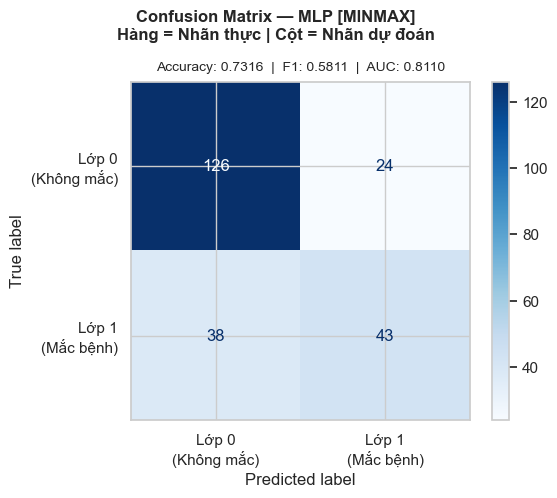

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle(
    f'Confusion Matrix — {best_model_name} [{best_scaler.upper()}]\n'
    'Hàng = Nhãn thực | Cột = Nhãn dự đoán',
    fontsize=12, fontweight='bold'
)
cm   = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Lớp 0\n(Không mắc)', 'Lớp 1\n(Mắc bệnh)']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(
    f'Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}',
    fontsize=10, pad=8
)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_confusion_matrix.png'), bbox_inches='tight')
plt.show()


## Bước 14: Classification Report

Báo cáo phân loại chi tiết theo từng lớp:
- **Precision / Recall / F1** — đánh giá riêng cho lớp 0 và lớp 1.
- **Support** — số mẫu thực tế của mỗi lớp trên tập test.
- **Macro avg** — trung bình không trọng số giữa các lớp.
- **Weighted avg** — trung bình có trọng số theo support, phù hợp khi mất cân bằng lớp.


In [5]:
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.7683    0.8400    0.8025       150
           1     0.6418    0.5309    0.5811        81

    accuracy                         0.7316       231
   macro avg     0.7050    0.6854    0.6918       231
weighted avg     0.7239    0.7316    0.7249       231



## Bước 15: ROC Curve và Ghi `test_log.xlsx`

Vẽ ROC Curve cho best model trên tập test hold-out, sau đó ghi kết quả theo đúng flow:
- Chỉ dùng **best model** đã export từ `02_train.ipynb`
- Chỉ dùng **file test** đã được xử lý ở `01_eda.ipynb`
- Composite ở bước test phải **khớp công thức** của bước train:
  `0.4 × Accuracy + 0.3 × F1 + 0.3 × ROC-AUC`


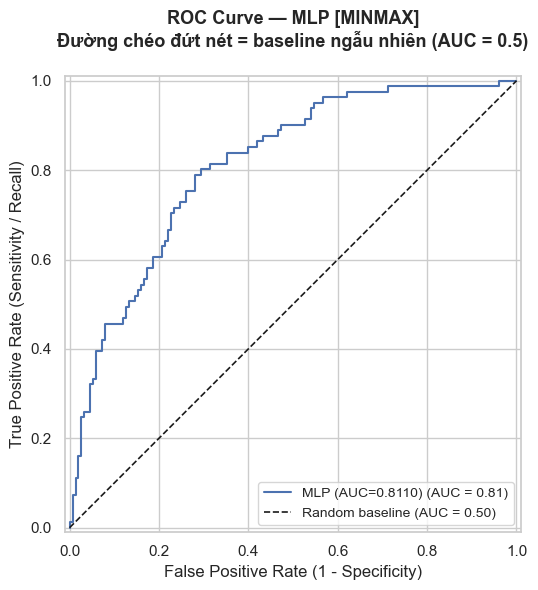

TỔNG KẾT TEST
Best model : MLP
Best scaler: minmax
Composite  : 0.71027
Test log   : D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes\test_log.xlsx


In [6]:
# ── ROC Curve ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(
    f'ROC Curve — {best_model_name} [{best_scaler.upper()}]\n'
    'Đường chéo đứt nét = baseline ngẫu nhiên (AUC = 0.5)',
    fontsize=13, fontweight='bold'
)

if hasattr(best_model, 'predict_proba'):
    score = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, 'decision_function'):
    score = best_model.decision_function(X_test)
else:
    score = None

if score is not None:
    RocCurveDisplay.from_predictions(
        y_test, score,
        name=f'{best_model_name} (AUC={auc:.4f})',
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_roc_curve.png'), bbox_inches='tight')
plt.show()

# ── Ghi log theo format mẫu ────────────────────────────────────────────────
run_end = datetime.now()
composite = round(
    0.4 * result.get('Accuracy', np.nan)
    + 0.3 * result.get('F1', np.nan)
    + 0.3 * (result.get('ROC_AUC', np.nan) if not np.isnan(result.get('ROC_AUC', np.nan)) else 0),
    5
)

summary_row = pd.DataFrame([{
    'Thời gian':      run_end.strftime('%Y-%m-%d %H:%M:%S'),
    'Train data':     DATA_NAME,
    'Test data':      DATA_NAME,
    'Best model':     best_model_name,
    'Best scaler':    best_scaler,
    'Composite':      composite,
    'Custom samples': 0,
    'Append custom':  False,
}])

bang_diem = pd.DataFrame([{
    'Scaler':           best_scaler,
    'Model':            best_model_name,
    'Accuracy':         result.get('Accuracy'),
    'F1':               result.get('F1'),
    'ROC_AUC':          result.get('ROC_AUC'),
    'Composite':        composite,
    'Labeled samples':  int(len(y_test)),
}])

# Predictions — toàn bộ X_test + nhãn thực + metadata + prediction + score
test_df_raw = pd.read_csv(FILES[best_scaler][1])
feat_cols   = test_df_raw.columns[:-1].tolist()
pred_df     = test_df_raw[feat_cols].copy()
pred_df['class']      = y_test
pred_df['source']     = 'official'
pred_df['scaler']     = best_scaler
pred_df['model']      = best_model_name
pred_df['prediction'] = y_pred

if score is not None:
    if hasattr(best_model, 'predict_proba'):
        classes = list(best_model.classes_)
        pos_idx = classes.index(1) if 1 in classes else (1 if len(classes) > 1 else 0)
        pred_df[f'prob_{classes[pos_idx]}'] = best_model.predict_proba(X_test)[:, pos_idx]
    else:
        pred_df['decision_score'] = score
else:
    pred_df['prob'] = np.nan

if os.path.exists(TEST_LOG):
    try:
        history = pd.concat(
            [pd.read_excel(TEST_LOG, sheet_name='Lich_su_chay'), summary_row],
            ignore_index=True
        )
    except Exception:
        history = summary_row
else:
    history = summary_row

with pd.ExcelWriter(TEST_LOG, engine='openpyxl', mode='w') as writer:
    history.to_excel(writer,   sheet_name='Lich_su_chay',  index=False)
    bang_diem.to_excel(writer, sheet_name='Bang_diem_test', index=False)
    pred_df.to_excel(writer,   sheet_name='Predictions',   index=False)

print('=' * 70)
print('TỔNG KẾT TEST')
print('Best model :', best_model_name)
print('Best scaler:', best_scaler)
print('Composite  :', composite)
print('Test log   :', TEST_LOG)
print('=' * 70)
